# 🌍 World Happiness Report 2015 — Analysis Pipeline
**Sections:** Loading → Cleaning → Preprocessing → Visualization

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

print('All libraries imported successfully')

All libraries imported successfully


## 2. Loading

In [ ]:
df = pd.read_csv('2015.csv')
print(df)
print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
df.head()

Shape: (158, 12)

Column names: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [3]:
print('Data types:')
print(df.dtypes)

Data types:
Country                              str
Region                               str
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object


## 3. Cleaning

In [4]:
# 3a. Check missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64


In [5]:
# 3b. Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Duplicates removed: {before - after}')

Duplicates removed: 0


In [6]:
# 3c. Rename columns to clean snake_case
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[()\/ ]', '', regex=True)
)
print('Cleaned column names:')
print(df.columns.tolist())

Cleaned column names:
['country', 'region', 'happiness_rank', 'happiness_score', 'standard_error', 'economy_gdp_per_capita', 'family', 'health_life_expectancy', 'freedom', 'trust_government_corruption', 'generosity', 'dystopia_residual']


In [7]:
# 3d. Fill numeric NaNs with column median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print('NaNs after filling:', df.isnull().sum().sum())

NaNs after filling: 0


In [8]:
# 3e. Descriptive statistics
df.describe()

,happiness_rank,happiness_score,standard_error,economy_gdp_per_capita,family,health_life_expectancy,freedom,trust_government_corruption,generosity,dystopia_residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


## 4. Preprocessing — scikit-learn
>  **Optional section** — only needed if you plan to use ML models.  
> You can skip this section if you only need EDA/visualization.

In [9]:
# 4a. Label Encode the 'region' column
# Converts text categories (e.g. 'Western Europe') into integers (0, 1, 2 ...)
# Useful when passing categorical data into ML models

le = LabelEncoder()
df['region_encoded'] = le.fit_transform(df['region'])

print('Region → Encoded label mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:>2}  →  {cls}')

Region → Encoded label mapping:
   0  →  Australia and New Zealand
   1  →  Central and Eastern Europe
   2  →  Eastern Asia
   3  →  Latin America and Caribbean
   4  →  Middle East and Northern Africa
   5  →  North America
   6  →  Southeastern Asia
   7  →  Southern Asia
   8  →  Sub-Saharan Africa
   9  →  Western Europe


In [10]:
# 4b. Min-Max Scaling on feature columns
# Scales all values to the range [0, 1]
# Needed for distance-based models (KNN, SVM, etc.) so no feature dominates

feature_cols = [
    'economy_gdp_per_capita',
    'family',
    'health_life_expectancy',
    'freedom',
    'trust_government_corruption',
    'generosity',
    'dystopia_residual',
]

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print('Scaled features (values now between 0 and 1):')
df_scaled[feature_cols].head()

Scaled features (values now between 0 and 1):


,economy_gdp_per_capita,family,health_life_expectancy,freedom,trust_government_corruption,generosity,dystopia_residual
0,0.826132,0.962403,0.918244,0.993789,0.760595,0.372895,0.668630
1,0.770412,1.000000,0.924496,0.938841,0.256292,0.548198,0.725030
2,0.784113,0.970297,0.853099,0.969615,0.876175,0.428947,0.660889
3,0.863099,0.949167,0.863409,1.000000,0.661394,0.435983,0.652724
4,0.784592,0.943219,0.883326,0.945112,0.597144,0.575602,0.648584


In [11]:
# 4c. What you can do next with scikit-learn:
# ─────────────────────────────────────────────────────────────
# from sklearn.linear_model import LinearRegression
# from sklearn.cluster import KMeans
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score
#
# Example — predict happiness score from features:
#   X = df_scaled[feature_cols]
#   y = df_scaled['happiness_score']
#   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#   model = LinearRegression()
#   model.fit(X_train, y_train)
#   print('R² score:', model.score(X_test, y_test))
# ─────────────────────────────────────────────────────────────
print('See comments above for scikit-learn usage examples.')

See comments above for scikit-learn usage examples.


## 5. Visualization

In [12]:
# Seaborn theme setup
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

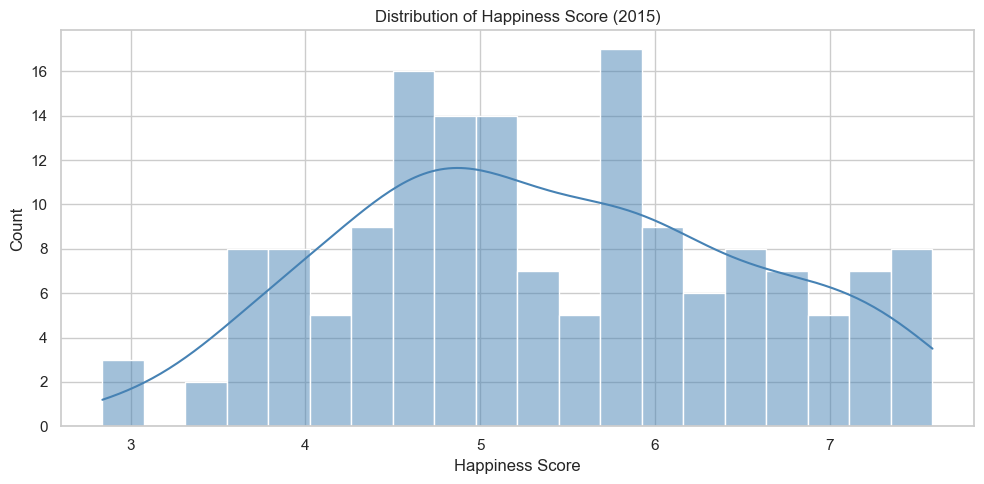

In [13]:
# 5a. Distribution of Happiness Score
plt.figure(figsize=(10, 5))
sns.histplot(df['happiness_score'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Happiness Score (2015)')
plt.xlabel('Happiness Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\mahmo\AppData\Local\Temp\ipykernel_9188\2751323843.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_avg, x='happiness_score', y='region', palette='Blues_d')


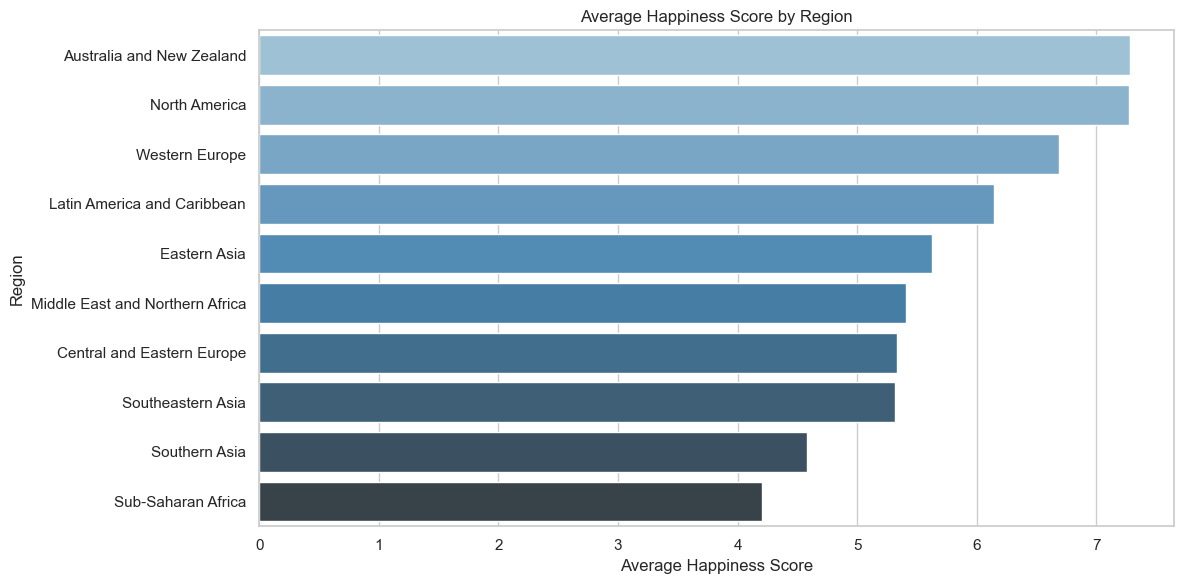

In [14]:
# 5b. Average Happiness Score by Region
region_avg = (
    df.groupby('region')['happiness_score']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=region_avg, x='happiness_score', y='region', palette='Blues_d')
plt.title('Average Happiness Score by Region')
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

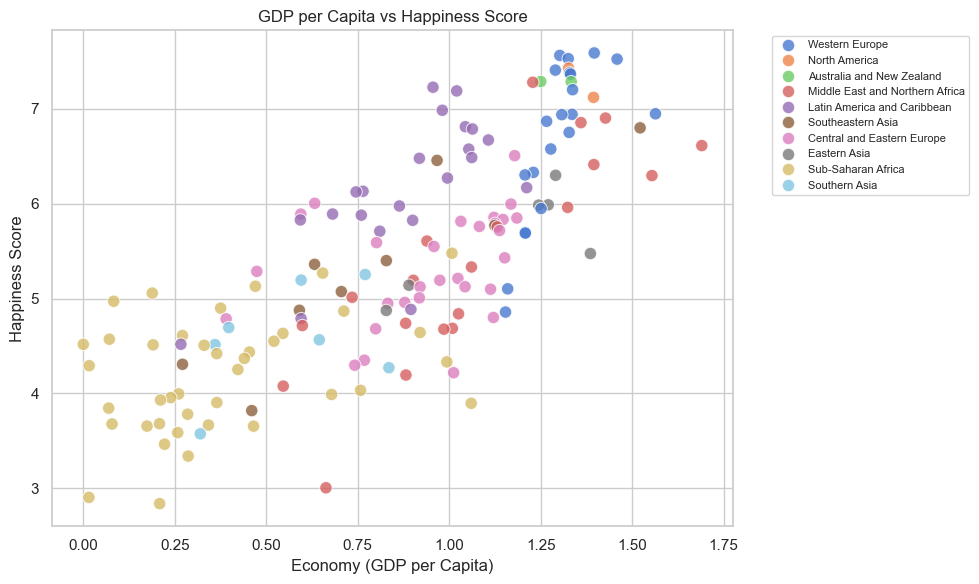

In [15]:
# 5c. GDP per Capita vs Happiness Score
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='economy_gdp_per_capita',
    y='happiness_score',
    hue='region',
    alpha=0.8,
    s=80,
)
plt.title('GDP per Capita vs Happiness Score')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

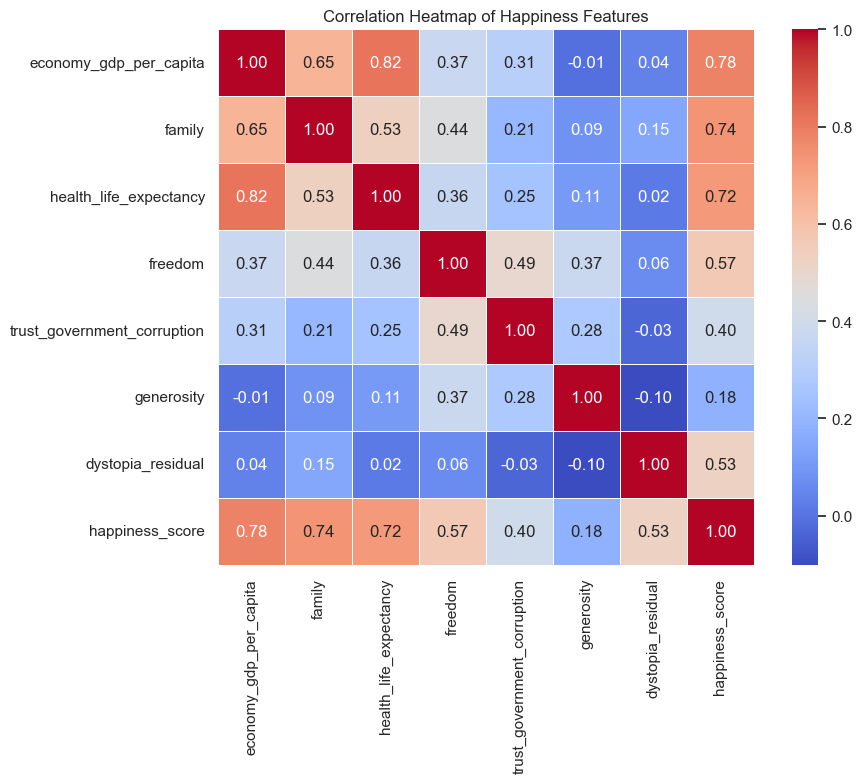

In [16]:
# 5d. Correlation Heatmap
feature_cols = [
    'economy_gdp_per_capita', 'family', 'health_life_expectancy',
    'freedom', 'trust_government_corruption', 'generosity',
    'dystopia_residual', 'happiness_score'
]

plt.figure(figsize=(10, 8))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Happiness Features')
plt.tight_layout()
plt.show()

C:\Users\mahmo\AppData\Local\Temp\ipykernel_9188\343934697.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


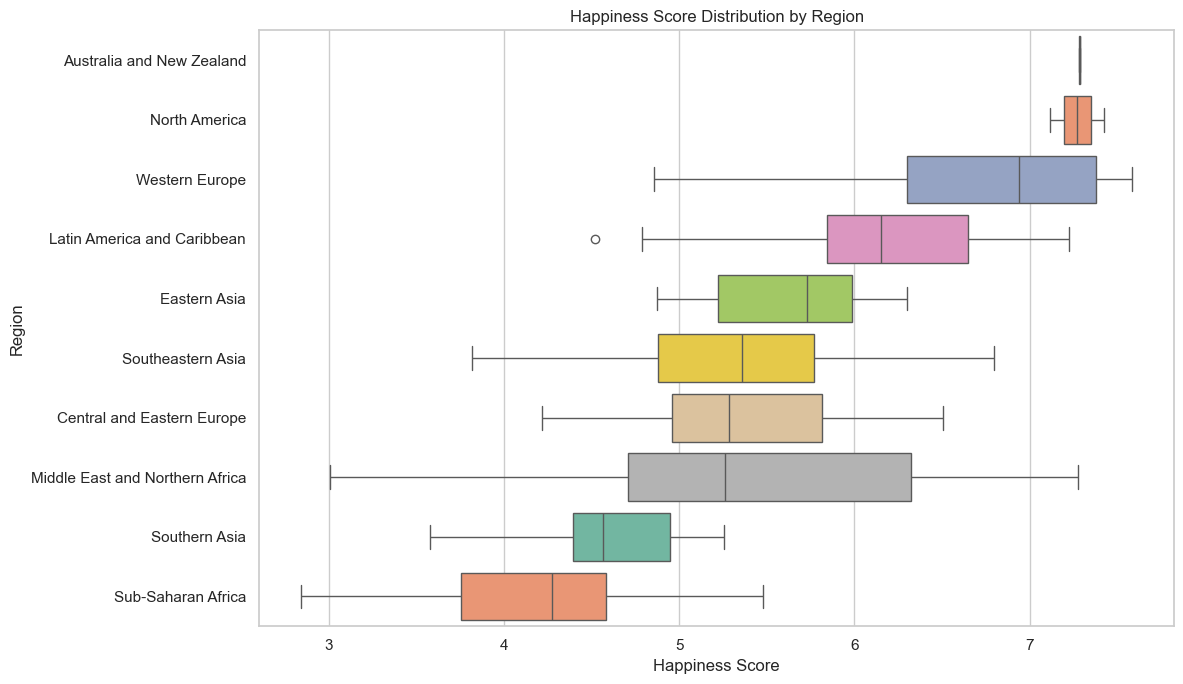

In [17]:
# 5e. Box Plot — Happiness Score by Region
region_order = (
    df.groupby('region')['happiness_score']
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df,
    x='happiness_score',
    y='region',
    order=region_order,
    palette='Set2',
)
plt.title('Happiness Score Distribution by Region')
plt.xlabel('Happiness Score')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

C:\Users\mahmo\AppData\Local\Temp\ipykernel_9188\309985829.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='happiness_score', y='country', palette='Greens_r', ax=axes[0])
C:\Users\mahmo\AppData\Local\Temp\ipykernel_9188\309985829.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x='happiness_score', y='country', palette='Reds_r', ax=axes[1])


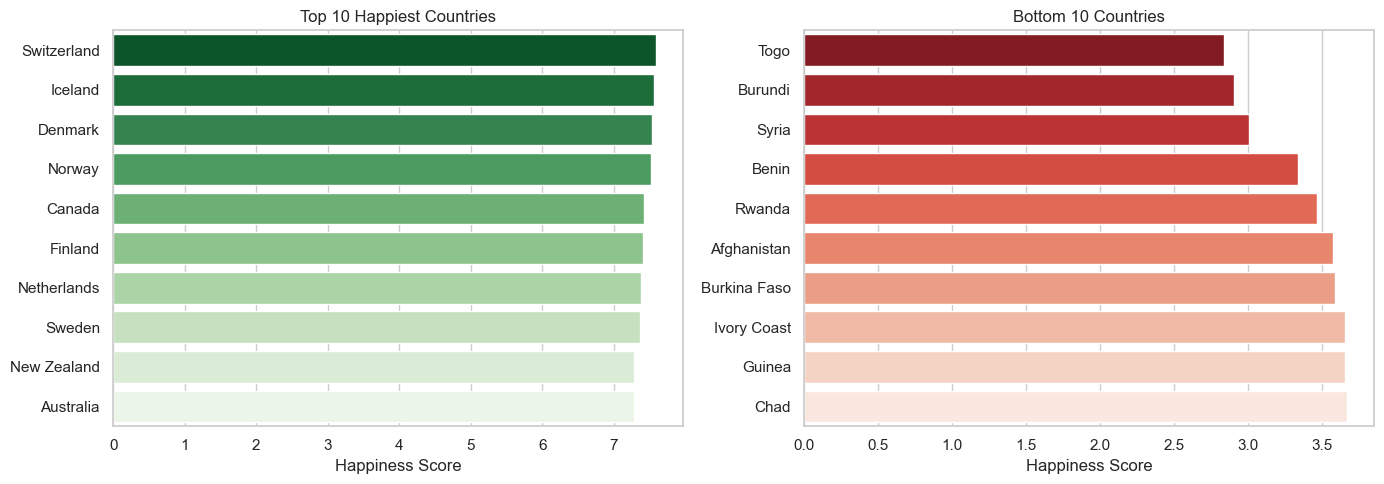

In [18]:
# 5f. Top 10 & Bottom 10 Countries
top10 = df.nlargest(10, 'happiness_score')[['country', 'happiness_score']]
bottom10 = df.nsmallest(10, 'happiness_score')[['country', 'happiness_score']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=top10, x='happiness_score', y='country', palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 10 Happiest Countries')
axes[0].set_xlabel('Happiness Score')
axes[0].set_ylabel('')

sns.barplot(data=bottom10, x='happiness_score', y='country', palette='Reds_r', ax=axes[1])
axes[1].set_title('Bottom 10 Countries')
axes[1].set_xlabel('Happiness Score')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()